In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from glob import glob

In [2]:
csv_path = '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv'
skin_df = pd.read_csv(csv_path)
skin_df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


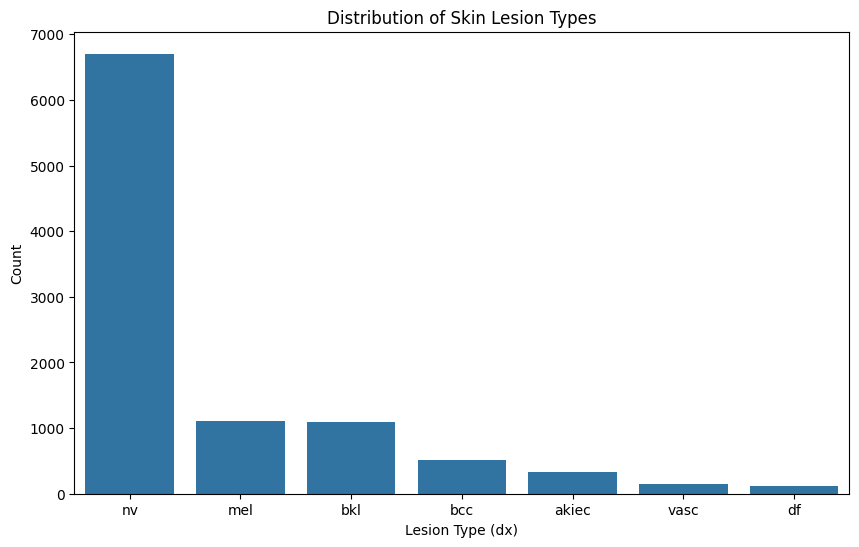

In [3]:
# Print the exact count of each lesion type (the 'dx' column stands for diagnosis)
print(skin_df['dx'].value_counts())

# Plotting the distribution as a bar chart
plt.figure(figsize=(10, 6))
sns.countplot(x='dx', data=skin_df, order=skin_df['dx'].value_counts().index)
plt.title('Distribution of Skin Lesion Types')
plt.xlabel('Lesion Type (dx)')
plt.ylabel('Count')
plt.show()

In [4]:
import os
from glob import glob

# Search for every .jpg file inside your 'data' folder (and any subfolders).
image_path_list = glob('/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/**/*.jpg', recursive=True)

# Creating a dictionary that links the image's base name to its full path.
image_path_dict = {os.path.splitext(os.path.basename(x))[0]: x for x in image_path_list}
skin_df['path'] = skin_df['image_id'].map(image_path_dict.get)
skin_df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnis...
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnis...
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnis...
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnis...
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/kaggle/input/datasets/kmader/skin-cancer-mnis...


In [5]:
#Checking for missing values
print(skin_df.isnull().sum())

lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
path             0
dtype: int64


In [6]:
from sklearn.model_selection import StratifiedGroupKFold

# Encoding the diagnosis labels as numbers so the splitter can stratify on them
skin_df['label'] = skin_df['dx'].astype('category').cat.codes

# Separating 80% of the data for Training and leaving 20% in a temporary set (images of the same lesion stay together)
train_idx, temp_idx = next(StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=123).split(
    skin_df, skin_df['label'], groups=skin_df['lesion_id']))
train_df, temp_df = skin_df.iloc[train_idx], skin_df.iloc[temp_idx]

# Spliting that temporary 20% equally into Validation (10%) and Testing (10%)
val_idx, test_idx = next(StratifiedGroupKFold(n_splits=2, shuffle=True, random_state=123).split(
    temp_df, temp_df['label'], groups=temp_df['lesion_id']))
val_df, test_df = temp_df.iloc[val_idx], temp_df.iloc[test_idx]

# Verifying the lengths of the new dataframes and that no lesion appears in more than one set
print(f"Training set: {len(train_df)} images")
print(f"Validation set: {len(val_df)} images")
print(f"Testing set: {len(test_df)} images")
print("Lesions shared between train and test:", len(set(train_df['lesion_id']) & set(test_df['lesion_id'])))

Training set: 8036 images
Validation set: 965 images
Testing set: 1014 images
Lesions shared between train and test: 0


In [7]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(train_df['dx'])

# Calculating standard balanced class weights
raw_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_df['dx']
)

# Applying square root dampening to prevent extreme over-correction on rare classes
dampened_weights = np.sqrt(raw_weights)

class_weights_dict = dict(enumerate(dampened_weights))
print("Optimized Class Weights:", class_weights_dict)

Optimized Class Weights: {0: np.float64(2.113510366674105), 1: np.float64(1.679475757681194), 2: np.float64(1.1560439949574006), 3: np.float64(3.4762351080322214), 4: np.float64(1.1389359688950638), 5: np.float64(0.46018370929599456), 6: np.float64(3.2015621187164243)}


In [8]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Targeting image size for transfer learning model and batch size
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Training generator WITH augmentation (preprocess_input scales pixels to the -1 to 1 range MobileNetV2 was trained on)
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=180,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='reflect'
)

# Validation and Testing generators WITHOUT augmentation (only the MobileNetV2 preprocessing)
val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Creating streaming image generators from dataframes
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df, x_col='path', y_col='dx', target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True, seed=123
)

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df, x_col='path', y_col='dx', target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df, x_col='path', y_col='dx', target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

Found 8036 validated image filenames belonging to 7 classes.
Found 965 validated image filenames belonging to 7 classes.
Found 1014 validated image filenames belonging to 7 classes.


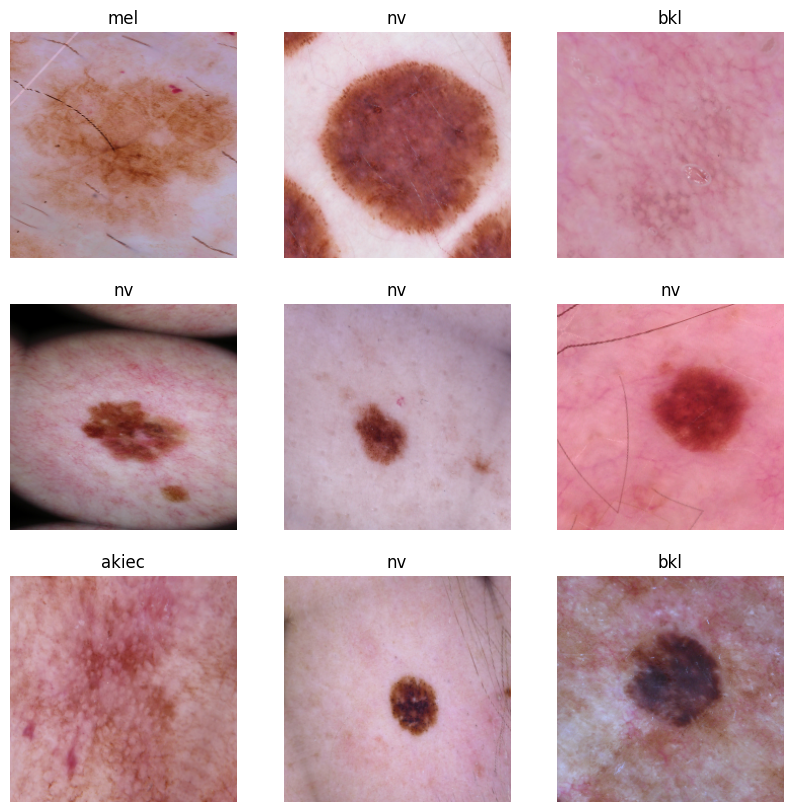

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Fetching a single batch of 32 augmented images and their one-hot encoded labels
images, labels = next(train_generator)
class_names = list(train_generator.class_indices.keys())

# Ploting a 3x3 grid of the first 9 images in the batch
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow((images[i] + 1) / 2) 
    plt.title(class_names[np.argmax(labels[i])])
    plt.axis("off")
plt.imshow((images[i] + 1) / 2)

In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Loading pre-trained MobileNetV2 base without top classifier
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# Freezing base layers so pretrained features are preserved
base_model.trainable = False

# Constructing custom classification head on top
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(7, activation='softmax')  # 7 classes
])

# Compiling model with Adam optimizer and Categorical Crossentropy loss
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall'), tf.keras.metrics.Precision(name='precision')]
)

model.summary()

I0000 00:00:1791220059.468246      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1791220059.472444      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,975 (9.26 MB)

 Trainable params: 167,431 (654.03 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [11]:
from tensorflow.keras.callbacks import Callback, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import recall_score

# Computing macro recall (average recall over the 7 classes) on the validation set after every epoch
class MacroRecall(Callback):
    def on_epoch_end(self, epoch, logs=None):
        val_generator.reset()
        preds = np.argmax(self.model.predict(val_generator, verbose=0), axis=1)
        logs['val_macro_recall'] = recall_score(val_generator.classes, preds, average='macro')
        print(f" - val_macro_recall: {logs['val_macro_recall']:.4f}")

# Stops training early if macro recall stops improving for 5 epochs, and keeps the best weights
early_stop = EarlyStopping(monitor='val_macro_recall', mode='max', patience=5, restore_best_weights=True)

# Reducing the learning rate if macro recall gets stuck
reduce_lr = ReduceLROnPlateau(monitor='val_macro_recall', mode='max', factor=0.5, patience=2, min_lr=1e-6)

# Training (MacroRecall has to come first in the list so the other callbacks can see its value)
print("Starting training phase...")
history = model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    class_weight=class_weights_dict,
    callbacks=[MacroRecall(), early_stop, reduce_lr]
)

Starting training phase...
Epoch 1/30


2026-10-05 17:08:01.420048: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 17:08:01.571683: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 17:08:01.710773: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1791220084.678349      74 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


209/252 ━━━━━━━━━━━━━━━━━━━━ 39s 927ms/step - accuracy: 0.5198 - loss: 1.5623 - precision: 0.5945 - recall: 0.4418

2026-10-05 17:11:26.687976: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 17:11:26.846662: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 17:11:26.982643: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


252/252 ━━━━━━━━━━━━━━━━━━━━ 0s 949ms/step - accuracy: 0.5322 - loss: 1.5176 - precision: 0.6084 - recall: 0.4555

2026-10-05 17:12:32.634303: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 17:12:32.771645: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 - val_macro_recall: 0.5775
252/252 ━━━━━━━━━━━━━━━━━━━━ 308s 1s/step - accuracy: 0.5936 - loss: 1.2900 - precision: 0.6766 - recall: 0.5224 - val_accuracy: 0.6663 - val_loss: 0.9078 - val_precision: 0.7749 - val_recall: 0.5316 - val_macro_recall: 0.5775 - learning_rate: 0.0010
Epoch 2/30
252/252 ━━━━━━━━━━━━━━━━━━━━ 0s 523ms/step - accuracy: 0.6532 - loss: 0.9747 - precision: 0.7360 - recall: 0.5685 - val_macro_recall: 0.5340
252/252 ━━━━━━━━━━━━━━━━━━━━ 146s 579ms/step - accuracy: 0.6538 - loss: 0.9631 - precision: 0.7428 - recall: 0.5719 - val_accuracy: 0.6674 - val_loss: 0.8055 - val_precision: 0.7768 - val_recall: 0.5699 - val_macro_recall: 0.5340 - learning_rate: 0.0010
Epoch 3/30
252/252 ━━━━━━━━━━━━━━━━━━━━ 0s 507ms/step - accuracy: 0.6802 - loss: 0.8788 - precision: 0.7797 - recall: 0.5928 - val_macro_recall: 0.5551
252/252 ━━━━━━━━━━━━━━━━━━━━ 142s 562ms/step - accuracy: 0.6807 - loss: 0.8781 - precision: 0.7799 - recall: 0.5884 - val_accuracy: 0.6819 - val_loss: 0.8019 - val

In [12]:
# Evaluating the model on the untouched testing data
print("Evaluating model on the test set...")
test_metrics = model.evaluate(test_generator)

# Extracting and printing the specific metrics defined during compilation
print("\n--- Final Test Results ---")
print(f"Loss:      {test_metrics[0]:.4f}")
print(f"Accuracy:  {test_metrics[1]:.4f}")
print(f"Recall:    {test_metrics[2]:.4f}")
print(f"Precision: {test_metrics[3]:.4f}")

Evaluating model on the test set...
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 598ms/step - accuracy: 0.5840 - loss: 1.0805 - precision: 0.7240 - recall: 0.4320

2026-10-05 17:25:10.206919: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 17:25:10.343225: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


32/32 ━━━━━━━━━━━━━━━━━━━━ 29s 920ms/step - accuracy: 0.6617 - loss: 0.8794 - precision: 0.8077 - recall: 0.5385

--- Final Test Results ---
Loss:      0.8794
Accuracy:  0.6617
Recall:    0.5385
Precision: 0.8077


In [13]:
# Efficientnet does not require rescaling.
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

#  Rebuilding Generators WITHOUT rescaling (EfficientNet handles it internally)
train_datagen_eff = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest'
)
val_test_datagen_eff = ImageDataGenerator() # Blank generator, no rescaling

# Re-streaming the dataframes
train_generator_eff = train_datagen_eff.flow_from_dataframe(
    dataframe=train_df, x_col='path', y_col='dx', target_size=(224, 224), 
    batch_size=32, class_mode='categorical', shuffle=True, seed=123
)
val_generator_eff = val_test_datagen_eff.flow_from_dataframe(
    dataframe=val_df, x_col='path', y_col='dx', target_size=(224, 224), 
    batch_size=32, class_mode='categorical', shuffle=False
)
test_generator_eff = val_test_datagen_eff.flow_from_dataframe(
    dataframe=test_df, x_col='path', y_col='dx', target_size=(224, 224), 
    batch_size=32, class_mode='categorical', shuffle=False
)

#  Rebuilding and Compiling EfficientNetB0
base_model_eff = tf.keras.applications.EfficientNetB0(
    input_shape=(224, 224, 3), include_top=False, weights='imagenet'
)
base_model_eff.trainable = False 

model_eff = models.Sequential([
    base_model_eff,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(7, activation='softmax')
])

model_eff.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall'), tf.keras.metrics.Precision(name='precision')]
)

# Training the unbiased model
print("Starting unbiased EfficientNetB0 training phase...")
history_eff = model_eff.fit(
    train_generator_eff,
    epochs=30,
    validation_data=val_generator_eff,
    class_weight=class_weights_dict, 
    callbacks=[early_stop, reduce_lr]
)

Found 8036 validated image filenames belonging to 7 classes.
Found 965 validated image filenames belonging to 7 classes.
Found 1014 validated image filenames belonging to 7 classes.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Starting unbiased EfficientNetB0 training phase...
Epoch 1/30


2026-10-05 17:25:38.816835: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 17:25:38.960826: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 17:25:39.311633: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 17:25:39.453462: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 17:25:40.264386: E external/local_xla/xla/stream_

148/252 ━━━━━━━━━━━━━━━━━━━━ 50s 490ms/step - accuracy: 0.4816 - loss: 1.5955 - precision: 0.5621 - recall: 0.4080

2026-10-05 17:27:04.331013: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 17:27:04.465666: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 17:27:04.776802: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 17:27:04.916711: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 17:27:05.743135: E external/local_xla/xla/stream_

252/252 ━━━━━━━━━━━━━━━━━━━━ 0s 537ms/step - accuracy: 0.5164 - loss: 1.4975 - precision: 0.5977 - recall: 0.4434

2026-10-05 17:28:18.781773: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 17:28:18.917896: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 17:28:19.233255: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 17:28:19.373072: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 17:28:20.133810: E external/local_xla/xla/stream_

252/252 ━━━━━━━━━━━━━━━━━━━━ 180s 621ms/step - accuracy: 0.5805 - loss: 1.3067 - precision: 0.6643 - recall: 0.5070 - val_accuracy: 0.6104 - val_loss: 1.0301 - val_precision: 0.7382 - val_recall: 0.4383 - learning_rate: 0.0010
Epoch 2/30


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_macro_recall` which is not available. Available metrics are: accuracy,loss,precision,recall,val_accuracy,val_loss,val_precision,val_recall
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/callback_list.py:171: UserWarning: Learning rate reduction is conditioned on metric `val_macro_recall` which is not available. Available metrics are: accuracy,loss,precision,recall,val_accuracy,val_loss,val_precision,val_recall,learning_rate.
  callback.on_epoch_end(epoch, logs)


252/252 ━━━━━━━━━━━━━━━━━━━━ 131s 520ms/step - accuracy: 0.6414 - loss: 0.9956 - precision: 0.7435 - recall: 0.5581 - val_accuracy: 0.6829 - val_loss: 0.7894 - val_precision: 0.7857 - val_recall: 0.5927 - learning_rate: 0.0010
Epoch 3/30
252/252 ━━━━━━━━━━━━━━━━━━━━ 131s 518ms/step - accuracy: 0.6711 - loss: 0.8946 - precision: 0.7655 - recall: 0.5790 - val_accuracy: 0.7161 - val_loss: 0.7959 - val_precision: 0.8282 - val_recall: 0.6093 - learning_rate: 0.0010
Epoch 4/30
252/252 ━━━━━━━━━━━━━━━━━━━━ 131s 518ms/step - accuracy: 0.6941 - loss: 0.8374 - precision: 0.7946 - recall: 0.5954 - val_accuracy: 0.6508 - val_loss: 0.8810 - val_precision: 0.7485 - val_recall: 0.5337 - learning_rate: 0.0010
Epoch 5/30
252/252 ━━━━━━━━━━━━━━━━━━━━ 130s 515ms/step - accuracy: 0.6956 - loss: 0.8006 - precision: 0.8038 - recall: 0.5959 - val_accuracy: 0.6798 - val_loss: 0.8141 - val_precision: 0.7588 - val_recall: 0.5575 - learning_rate: 0.0010
Epoch 6/30
252/252 ━━━━━━━━━━━━━━━━━━━━ 128s 509ms/step - a

In [14]:
# Evaluating EfficientNetB0 using the unscaled test generator
print("Evaluating EfficientNetB0 on the unscaled test set...")
test_metrics_eff = model_eff.evaluate(test_generator_eff)

# Extracting and printing the correct test metrics
print("\n--- EfficientNetB0 Final Test Results ---")
print(f"Loss:      {test_metrics_eff[0]:.4f}")
print(f"Accuracy:  {test_metrics_eff[1]:.4f}")
print(f"Recall:    {test_metrics_eff[2]:.4f}")
print(f"Precision: {test_metrics_eff[3]:.4f}")

Evaluating EfficientNetB0 on the unscaled test set...
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - accuracy: 0.6463 - loss: 0.9384 - precision: 0.7212 - recall: 0.5387

2026-10-05 18:31:29.755608: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 18:31:29.897686: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 18:31:30.231003: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 18:31:30.372783: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 18:31:31.151468: E external/local_xla/xla/stream_

32/32 ━━━━━━━━━━━━━━━━━━━━ 16s 517ms/step - accuracy: 0.7130 - loss: 0.8277 - precision: 0.8084 - recall: 0.6282

--- EfficientNetB0 Final Test Results ---
Loss:      0.8277
Accuracy:  0.7130
Recall:    0.6282
Precision: 0.8084


In [15]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    'best_model_eff.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)